## Example Case Study: MoCoDo 2024 Formulation
- **Base:** Setting ESS rated power $sz^E$ to be 2% of OWF rated power; fixing $k^{ResB}$ and $k^{ResW}$ at their upper limits for providing maximum frequency support; using one or more HVDC cables with fixed rated power of 2600 MW; 3% inflation; data of 2018
- **CCD18-3**, **CCD18-5**, and **CCD18-8**: CCD model with 3%, 5%, and 8% reflation rate; data of 2018
- **CCD22-3**, **CCD22-5**, and **CCD22-8**: CCD model with 3%, 5%, and 8% reflation rate; data of 2022
- **No reserve**: Same as CCD18-3 case, but no reserve is provided for frequency support
- **No ESS**: Same as CCD18-3 case, but no ESS installed

#### Terminologies:
- $sz^E$: Rated power of ESS
- $k^{ResB}$: Droop control parameters of ESS
- $k^{ResW}$: Droop control parameters of OWF
- Reflection rate: Quantifies how much of the transmitted power is reflected back towards the source due to impedance mismatches in the system.

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload 
from tslearn.clustering import TimeSeriesKMeans

In [2]:
USER_PATH = '../../../data/DataExchangeMilan_Project2.2a'
DATA_PATH = 'processed'

path = os.path.join(os.path.expanduser(USER_PATH), DATA_PATH)

# os.listdir(path)

In [3]:
df_design = pd.read_csv(os.path.join(path, 'design_solutions.csv'), index_col=[0, 1])#.loc[(slice(None), 'TESLA'), :]
df_design

Cable Capacity(MW)  Battery Rated Power(MW)  \
Use Case   Location                                                  
Base       COTTONWOOD         2600.000000                36.200000   
           JOHNDAY            2600.000000                47.000000   
           MOSSLAND           2600.000000                36.000000   
           TESLA              5200.000000                52.800000   
           WCASCADE           2600.000000                30.000000   
No ESS     COTTONWOOD         1991.001203                 0.000000   
           JOHNDAY            2585.000202                 0.000000   
           MOSSLAND           1980.000054                 0.000000   
           TESLA              2904.000009                 0.000000   
           WCASCADE           1650.001811                 0.000000   
No Reserve COTTONWOOD         1991.000362                 0.015596   
           JOHNDAY            2585.000076                 0.002795   
           MOSSLAND           1980.000015                 0.002201   
           TESLA              2904.000016                 0.001348   
           WCASCADE           1650.000131                 0.008876   
CCD18_3    COTTONWOOD         1991.029248                54.300003   
           JOHNDAY            2585.009992                70.499999   
           MOSSLAND           1980.003137                53.999993   
           TESLA              2904.001129                79.200000   
           WCASCADE           1650.006081                45.000000   
CCD18_5    COTTONWOOD         1991.037056                54.299998   
           JOHNDAY            2585.013157                70.499883   
           MOSSLAND           1980.001935                53.996802   
           TESLA              2904.001711                79.199999   
           WCASCADE           1650.007926                44.999968   
CCD18_8    COTTONWOOD         1991.058035                52.534622   
           JOHNDAY            2584.999080                61.202332   
           MOSSLAND           1979.998289                39.936632   
           TESLA              2904.008432                65.888878   
           WCASCADE           1650.023596                40.079054   
CCD22_3    COTTONWOOD         1991.023489                90.499991   
           JOHNDAY            2585.003001               117.500000   
           MOSSLAND           1980.046451                89.999778   
           TESLA              2904.004155               131.999982   
           WCASCADE           1650.006875                75.000000   
CCD22_5    COTTONWOOD         1991.036236                90.498599   
           JOHNDAY            2585.004206               117.499458   
           MOSSLAND           1980.019071                89.999729   
           TESLA              2904.003173               131.999984   
           WCASCADE           1650.005357                75.000000   
CCD22_8    COTTONWOOD         1991.064793                54.300083   
           JOHNDAY            2585.007466                70.500001   
           MOSSLAND           1980.027603                54.000123   
           TESLA              2904.004470                79.200095   
           WCASCADE           1650.015151                45.000245   

                       Cable Material Cost($M)  Battery Cost($M)  \
Use Case   Location                                                
Base       COTTONWOOD               261.818246         32.184081   
           JOHNDAY                  358.915986         41.785961   
           MOSSLAND                 533.607121         32.006268   
           TESLA                    974.931412         46.942526   
           WCASCADE                 440.190421         26.671890   
No ESS     COTTONWOOD               200.492478          0.000000   
           JOHNDAY                  356.845345          0.000000   
           MOSSLAND                 406.362357          0.000000   
           TESLA                    544.461698      

## Task-1: Find the "best" solution
However, "best" could mean different to different people. 

### Definition-1 => Best: Use case that maximises the total revenue.

In [4]:
revenue_cols = [c for c in df_design.columns if "Revenue" in c]
max_profit = df_design[revenue_cols].sum(axis=1).unstack().apply(lambda x: (x.idxmax(), x.max())).T
max_profit.columns = ["Use Case", "Total Revenue"]
min_profit = df_design[revenue_cols].sum(axis=1).unstack().apply(lambda x: (x.idxmin(), x.min())).T
min_profit.columns = ["Use Case", "Total Revenue"]

print("Best Solution")
display(max_profit)
print("Worst Solution")
display(min_profit)

Best Solution


,Use Case,Total Revenue
Location,,
COTTONWOOD,CCD22_5,2550.953004
JOHNDAY,CCD22_5,3033.245072
MOSSLAND,CCD22_3,2120.156138
TESLA,CCD22_5,3387.877511
WCASCADE,CCD22_5,2122.153838


Worst Solution


,Use Case,Total Revenue
Location,,
COTTONWOOD,Base,1073.068327
JOHNDAY,Base,1352.692062
MOSSLAND,Base,950.822751
TESLA,Base,1476.519093
WCASCADE,Base,905.061908


#### Comparison with paper findings:
- *Significantly higher profits are observed in cases using 2022 data, reflecting the much higher energy prices compared to 2018.*
- *The base case, which provides the largest reserve for frequency support, yields the lowest profit.*

### Definition-2 => Best: Use case that minimizes the total cost.

In [5]:
revenue_cols = [c for c in df_design.columns if "Cost" in c]
max_cost = df_design[revenue_cols].sum(axis=1).unstack().apply(lambda x: (x.idxmax(), x.max())).T
max_cost.columns = ["Use Case", "Total Cost"]
min_cost = df_design[revenue_cols].sum(axis=1).unstack().apply(lambda x: (x.idxmin(), x.min())).T
min_cost.columns = ["Use Case", "Total Cost"]

print("Best Solution")
display(min_cost)
print("Worst Solution")
display(max_cost)

Best Solution


,Use Case,Total Cost
Location,,
COTTONWOOD,No ESS,200.492478
JOHNDAY,No ESS,356.845345
MOSSLAND,No ESS,406.362357
TESLA,No ESS,544.461698
WCASCADE,No ESS,279.35192


Worst Solution


,Use Case,Total Cost
Location,,
COTTONWOOD,Base,294.002327
JOHNDAY,CCD22_3,461.310634
MOSSLAND,Base,565.613389
TESLA,Base,1021.873939
WCASCADE,Base,466.862311


## Defining Best/Worst on Multiple Objectives

When dealing with multiple objectives, there is no optimal solution that works best for all the objectives - there are tradeoffs. However, there could be "optimal" solutions from different perspectives. Our AI algorithm identifies an "optimal" solution from four different perspectives:
- Specializers: Solutions that specialise in one specific objective
- Generalizers: Solutions that generalise across multiple objectives. A generalizer is the minimum worst ranking across all the objectives. 
- Resilient: Solutions that are resilient across diverse scenarios
- Sensitive: Solutions that are sensitive to scenarios

In [6]:
sys.path.append("../")
import tradeoff_lattice as tl; reload(tl)

ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

def ovar_format(s):
    sep = ' Revenue'
    if ' Cost' in s:
        sep = ' Cost'

    left, right = s.split(sep)
    return f'{left}\n{sep[1:]}{right}'
    
ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)



/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Definition-3: Best: Solution that generalize well across all objectives 
A generalizer is a solution whose worst rank (across objectives) is best across all the solutions.

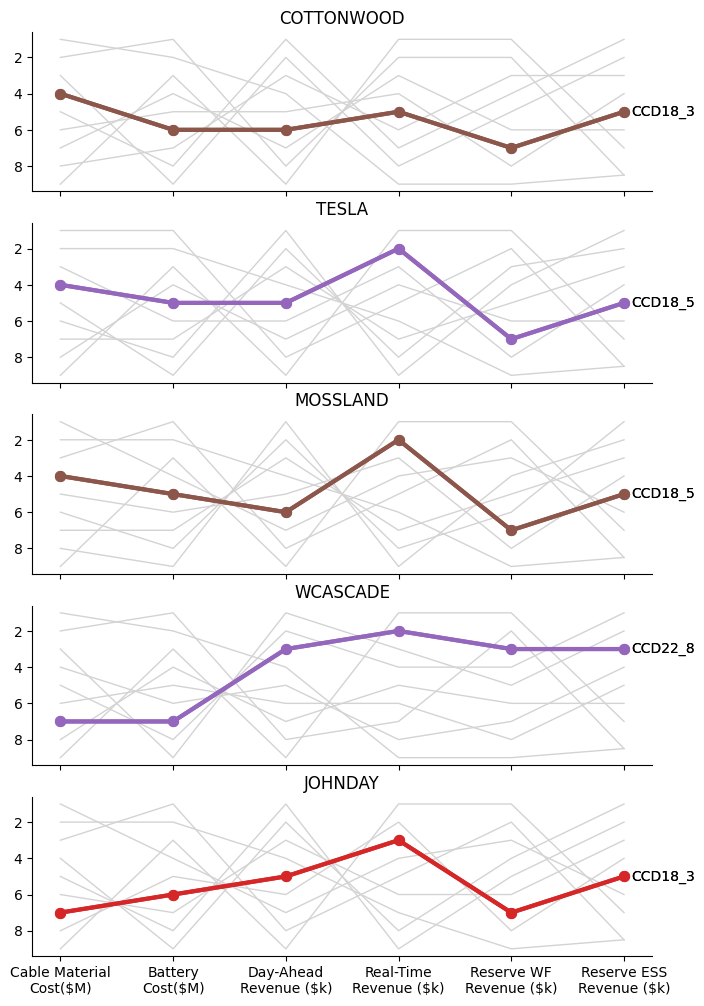

In [7]:
locations = ["COTTONWOOD", "TESLA", "MOSSLAND", "WCASCADE", "JOHNDAY"]
n_cols = 3
n_rows = (len(locations) // n_cols) + 1

fig, axes = plt.subplots(len(locations), 1, figsize=(8, 12), sharex=True, sharey=True)
# fig, axes = plt.subplots(1, len(locations), figsize=(12, 4), sharex=True, sharey=True)
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_rows, 3*n_cols), sharex=True, sharey=True)
for indx, loc in enumerate(locations):
    self = tl.DirectTradeoffLattice(
        df_design.loc[(slice(None), loc), :].droplevel(1), ovars, dvars,
        ascending=ascending,
        # max_specializers=1,
        # min_specializers=1,
        n_generalizers=1,
    )
    
    ax = axes[indx]
    self.plot_ovars_parallel_coords(
        x_label_format=ovar_format,
        use_rank=True,
        include_all_generalizers=True,
        reorder=False,
        highlight_generalizers=True,
        ax = ax
        # facets = [
        #     i[1]
        #     for i in self.rank.index
        # ]
    )
    ax.set_title(loc)
# fig.title(loc)
# fig.subplots_adjust(hspace=1)

#### Notes:
- *CCD18_3 and CCD18_5 generalize well across multiple objectives in most locations. In WCASCADE, CCD22_8, generalize better than CCD18_3 and CCD18_5. In WCASCADE, CCD18_3 and CCD18_5 does worse on Cable Material Cost and Reserve WF Revenue.*
    * <font color='red'>Do we expect CCD18 to average well across all objectives? Why? </font>

#### Scope for improvement:
- Weight assignment to objectives when ranking solutions.
- Better tie breaker when getting the generalizers.

In [8]:
self = tl.DirectTradeoffLattice(
        df_design.loc[(slice(None), loc), :].droplevel(1), ovars, dvars,
        ascending=ascending,
        # max_specializers=1,
        # min_specializers=1,
        n_generalizers=1,
    )
self.rank.loc[["CCD18_3", "CCD18_5", "CCD22_8"]]

,Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
Use Case,,,,,,
CCD18_3,7.0,6.0,5.0,3.0,7.0,5.0
CCD18_5,8.0,5.0,6.0,2.0,8.0,4.0
CCD22_8,6.0,7.0,3.0,6.0,6.0,3.0


### Definition-4: Best: A set of solutions that specialize in at least one objective.
A specializer here is defined as a solution which is better than the generalizer in atleast one objective function. This will usually give a set of solutions rather than a solution

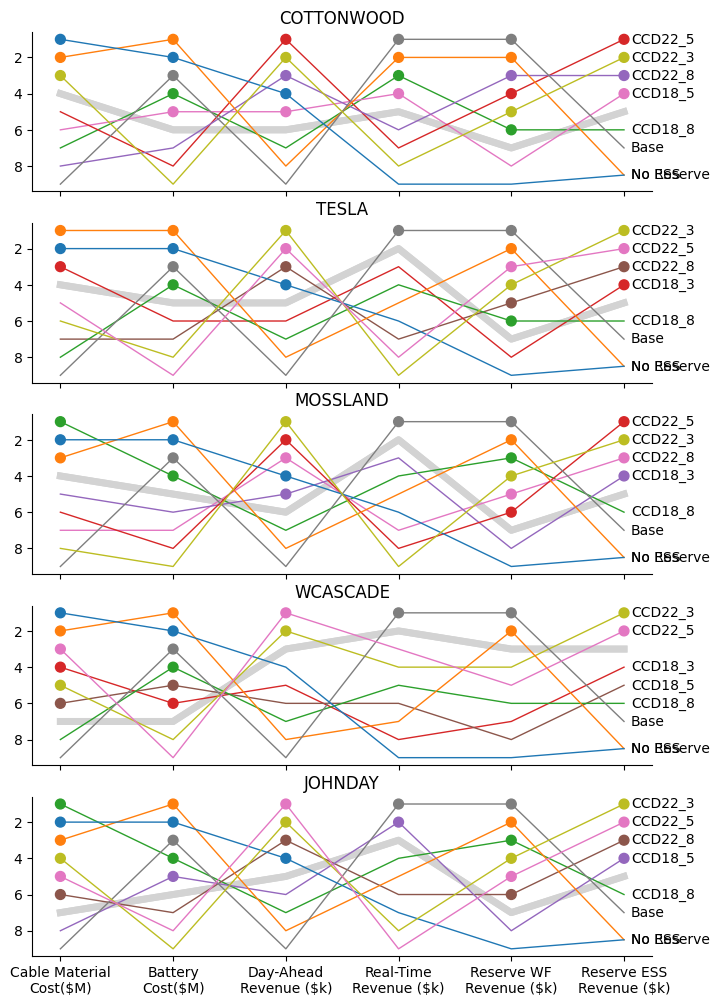

In [9]:
n_cols = 3
n_rows = (len(locations) // n_cols) + 1

fig, axes = plt.subplots(len(locations), 1, figsize=(8, 12), sharex=True, sharey=True)
for indx, loc in enumerate(locations):
    self = tl.DirectTradeoffLattice(
        df_design.loc[(slice(None), loc), :].droplevel(1), ovars, dvars,
        ascending=ascending,
        # max_specializers=1,
        # min_specializers=1,
        n_generalizers=1,
    )
    
    ax = axes[indx]
    self.plot_ovars_parallel_coords(
        x_label_format=ovar_format,
        use_rank=True,
        include_all_generalizers=True,
        reorder=False,
        highlight_generalizers=False,
        ax = ax
        # facets = [
        #     i[1]
        #     for i in self.rank.index
        # ]
    )
    ax.set_title(loc)
    # plt.title(loc)
    
    # plt.subplots_adjust(hspace=1)

#### Notes:
- *You will expect multiple specializers since we are looking for solutions that specialize in at least one objective than a generalizer*
- *In most locations, a very few specializers in real-time revenue.*
- *Specializers usually do better than the generalizer in cost objectives and reserve WF revenue.*

#### Scope for improvement:
- Putting an at least limit (min_specialization) to further reduce this subset, i.e., the solution must specialize in at lease two objective functions to be in this set. 
- Minimum number of solutions to cover all objective functions. 

## Can we extend this analysis to scenarios?
- Which scenario is the best - maximize overall revenue?
- Which scenario is the worst - minimal revenue?
- Which scenarios are better for specific objectives?
- Which scenarios are better in generalising well across multiple objectives?

In [10]:
ascending = []
ovars_scenario = ovars[2:]
sel_index = "Base_cotwdpge"
df_design_scenario = pd.read_csv(os.path.join(path, 'design_solutions_per_scenario.csv'), index_col=[0, 1]).loc[sel_index]
summary_frame = df_design_scenario.describe().T

rated_power = df_design_scenario["Cable Capacity(MW)"].unique()[0]
df_design_scenario

,Cable Capacity(MW),Battery Rated Power(MW),Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
sim,,,,,,,,
22,2600.0,36.2,261.818246,32.184081,53.342842,-11.589288,0.004268,0.004710
23,2600.0,36.2,261.818246,32.184081,53.342842,-3.006324,0.000850,0.002057
24,2600.0,36.2,261.818246,32.184081,53.342842,-5.214967,0.001355,0.001465
25,2600.0,36.2,261.818246,32.184081,53.342842,2.644101,0.000654,0.000158
26,2600.0,36.2,261.818246,32.184081,53.342842,17.872314,0.023466,0.004765
...,...,...,...,...,...,...,...,...
117,2600.0,36.2,261.818246,32.184081,1.201874,0.073118,0.000046,0.001611
118,2600.0,36.2,261.818246,32.184081,1.201874,0.206525,0.000383,0.001360
119,2600.0,36.2,261.818246,32.184081,1.201874,-0.205468,0.000567,0.009071


In [11]:
df_scenario = pd.read_csv(os.path.join(path, 'scenarios_wrevenues.csv'), index_col=[0, 1, 2]).loc[sel_index]
df_scenario

ChS      DisS        SCS       WPQ       WSQ  kBS       kWS  \
sim time                                                                     
22  0     0.005304  0.002016  72.400653  0.000000  1.631244  2.0  0.000000   
    1     0.006830  0.001833  72.401701  0.000000  1.631244  2.0  0.000000   
    2     0.009288  0.001677  72.403353  0.000000  1.631244  2.0  0.000000   
    3     0.013716  0.001543  72.406050  0.000000  1.631244  2.0  0.000000   
    4     0.024299  0.001415  72.411189  0.000000  1.656754  2.0  0.000000   
...            ...       ...        ...       ...       ...  ...       ...   
121 91    0.057586  0.181982   0.138868  1.143338  2.831317  2.0  0.006317   
    92    0.094833  0.116952   0.128312  0.000000  2.741472  2.0  0.000000   
    93    0.087642  0.137289   0.110534  0.000000  2.741472  2.0  0.000000   
    94    0.080859  0.173926   0.081147  0.000000  2.741472  2.0  0.000000   
    95    0.073323  0.286643   0.019080  0.000000  2.741472  2.0  0.000000   

                lam_DAQ         lam_RT     pRBDS  ...      pWSQ          v1  \
sim time                                          ...                         
22  0     111068.493725  113957.371061  1.508333  ...  0.000000  475.731414   
    1     111068.493725  111151.766882  1.508333  ...  0.000000  475.729736   
    2     111068.493725  108346.162703  1.508333  ...  0.000000  475.728057   
    3     111068.493725  105540.558524  1.508333  ...  0.000000  475.726378   
    4     100218.649657  102734.954344  1.508333  ...  0.000000  475.723523   
...                 ...            ...       ...  ...       ...         ...   
121 91    163680.830824  134271.586201  1.508333  ...  1.093234  480.217598   
    92    148412.687808  131484.129416  1.508333  ...  0.000000  475.671659   
    93    148412.687808  130878.298467  1.508333  ...  0.000000  475.671371   
    94    148412.687808  130272.467519  1.508333  ...  0.000000  475.671202   
    95    148412.687808  129666.636570  1.508333  ...  0.000000  475.670965   

                  v2        WS        pWDS       pWS  Day-Ahead Revenue ($k)  \
sim time                                                                       
22  0     475.731415  1.631244  750.441807  0.000000                1.825421   
    1     475.729736  1.631244  750.441807  0.000000                     NaN   
    2     475.728058  1.631244  750.441807  0.000000                     NaN   
    3     475.726379  1.631244  750.441807  0.000000                     NaN   
    4     475.723523  1.656754  716.536060  0.000000                1.572685   
...              ...       ...         ...       ...                     ...   
121 91    480.212294  2.831317   43.235001  1.093234                     NaN   
    92    475.671675  2.741472    4.894323  0.000000                0.003889   
    93    475.671388  2.741472    4.894323  0.000000                     NaN   
    94    475.671220  2.741472    4.894323  0.000000                     NaN   
    95    475.670985  2.741472    4.894323  0.000000                     NaN   

          Reserve ESS Revenue ($k)  Reserve WF Revenue ($k)  \
sim time                                                      
22  0                 2.756143e-05             0.000000e+00   
    1                 2.818572e-05             0.000000e+00   
    2                 2.881002e-05             0.000000e+00   
    3                 2.943431e-05             0.000000e+00   
    4                 3.005861e-05             0.000000e+00   
...                            ...                      ...   
121 91                5.802918e-07             1.807893e-09   
    92                8.794077e-08             0.000000e+00   
    93                4.331705e-08             0.000000e+00   
    94               -1.306666e-09             0.000000e+00   
    95               -4.593039e-08             0.000000e+00   

          Real-Time Revenue ($k)  
sim time                          
22  0                  -0.169856  
    1 

In [12]:
def plot_scenario(scenario_frame, rated_power, s):
    scenario_frame["pink_column"] = (scenario_frame["lam_RT"] > scenario_frame["lam_DAQ"]).astype(int)

    fig, ax = plt.subplots(2, 4, figsize=(16, 5))
    fig.suptitle(f"Scenario ID: {s}", fontsize=18)

    sel_ax = ax[0, 0]
    (scenario_frame[["pWRS", "pWDSQ"]] / 1000).plot(ax=sel_ax, zorder=1)
    (scenario_frame[["pWSQ"]] / 1000).plot(ax=sel_ax, color='k', zorder=1)
    sel_ax.set_xlabel("Time (15-min Intervals)")
    sel_ax.set_ylabel("Market Participation (GW)")
    sel_ax.legend(["RT Market Participation", "DA Market Participation", "WF Output"])
    for t in scenario_frame.loc[scenario_frame['pink_column'] == 1].index:
        sel_ax.axvline(x=t, color='pink', linestyle='-', alpha=0.2)
    
    sel_ax = ax[0, 1]
    (scenario_frame[["lam_DAQ"]] / rated_power).plot(ax=sel_ax)
    sel_ax.set_xlabel("Time (15-min Intervals)")
    sel_ax.set_ylabel("Prices ($/MWh)")
    sel_ax.legend(["DA Price"])
    (df_scenario["lam_DAQ"].unstack().T.ffill() / rated_power).plot(ax=sel_ax, color='lightgrey', legend=False, lw=0.5, alpha=0.5, zorder=0)
    
    sel_ax = ax[0, 2]
    (scenario_frame[["lam_RT"]] / rated_power).plot(ax=sel_ax)
    sel_ax.set_xlabel("Time (15-min Intervals)")
    sel_ax.set_ylabel("Prices ($/MWh)")
    sel_ax.legend(["RT Price"])
    (df_scenario["lam_RT"].unstack().T.ffill() / rated_power).plot(ax=sel_ax, color='lightgrey', legend=False, lw=0.5, alpha=0.5, zorder=0)
    
    # (scenario_frame["DisS"]-scenario_frame["ChS"]).plot(ax=ax[0, 2], color='red', zorder=1)
    # ax[0, 2].set_xlabel("Time (15-min Intervals)")
    # ax[0, 2].set_ylabel("BESS Discharge (MW)")
    # for t in scenario_frame.loc[scenario_frame['pink_column'] == 1].index:
    #     ax[0, 2].axvline(x=t, color='pink', linestyle='-', alpha=0.2)

    (df_scenario["WS"].unstack().T.ffill()).plot(ax=ax[0, 3], color='lightgrey', legend=False, lw=0.5, alpha=0.5)
    (scenario_frame["WS"]).plot(ax=ax[0, 3], color='red', zorder=1)
    ax[0, 3].set_xlabel("Time (15-min Intervals)")
    ax[0, 3].set_ylabel("Wind Speed")
    
    (df_scenario["Day-Ahead Revenue ($k)"].unstack().T.ffill()).plot(ax=ax[1, 0], color='lightgrey', legend=False, lw=0.5, alpha=0.5)
    (scenario_frame[["Day-Ahead Revenue ($k)"]].ffill()).plot(ax=ax[1, 0])
    ax[1, 0].set_xlabel("Time (15-min Intervals)")
    
    (df_scenario["Real-Time Revenue ($k)"].unstack().T.ffill()).plot(ax=ax[1, 1], color='lightgrey', legend=False, lw=0.5, alpha=0.5)
    (scenario_frame[["Real-Time Revenue ($k)"]]).plot(ax=ax[1, 1])
    ax[1, 1].set_xlabel("Time (15-min Intervals)")
    
    df_scenario["Reserve ESS Revenue ($k)"].unstack().T.ffill().plot(ax=ax[1, 2], color='lightgrey', legend=False, lw=0.5, alpha=0.5)
    (scenario_frame[['Reserve ESS Revenue ($k)']]).plot(ax=ax[1, 2])
    ax[1, 2].set_xlabel("Time (15-min Intervals)")
    
    df_scenario["Reserve WF Revenue ($k)"].unstack().T.ffill().plot(ax=ax[1, 3], color='lightgrey', legend=False, lw=0.5, alpha=0.5)
    (scenario_frame[['Reserve WF Revenue ($k)']]).plot(ax=ax[1, 3])
    ax[1, 3].set_xlabel("Time (15-min Intervals)")
    
    fig.tight_layout()

### Which scenario is the best - maximizing total revenue (sum of objective functions)
In which scenario, do we maximize the total revenue? Total revenue is computed by summing up revenue across all the revenue related objective functions. 

,count,mean,std,min,25%,50%,75%,max,selected_solution
Day-Ahead Revenue ($k),100.0,52.037997,32.823280,1.201874,26.837089,52.842652,68.323501,136.196299,136.196299
Real-Time Revenue ($k),100.0,0.290401,6.120973,-17.387559,-3.025179,1.139057,4.716428,17.872314,10.871624
Reserve WF Revenue ($k),100.0,0.025298,0.026578,0.000046,0.005135,0.018360,0.040850,0.186279,0.078170
Reserve ESS Revenue ($k),100.0,0.007385,0.005302,0.000125,0.003399,0.006763,0.010169,0.038544,0.015887


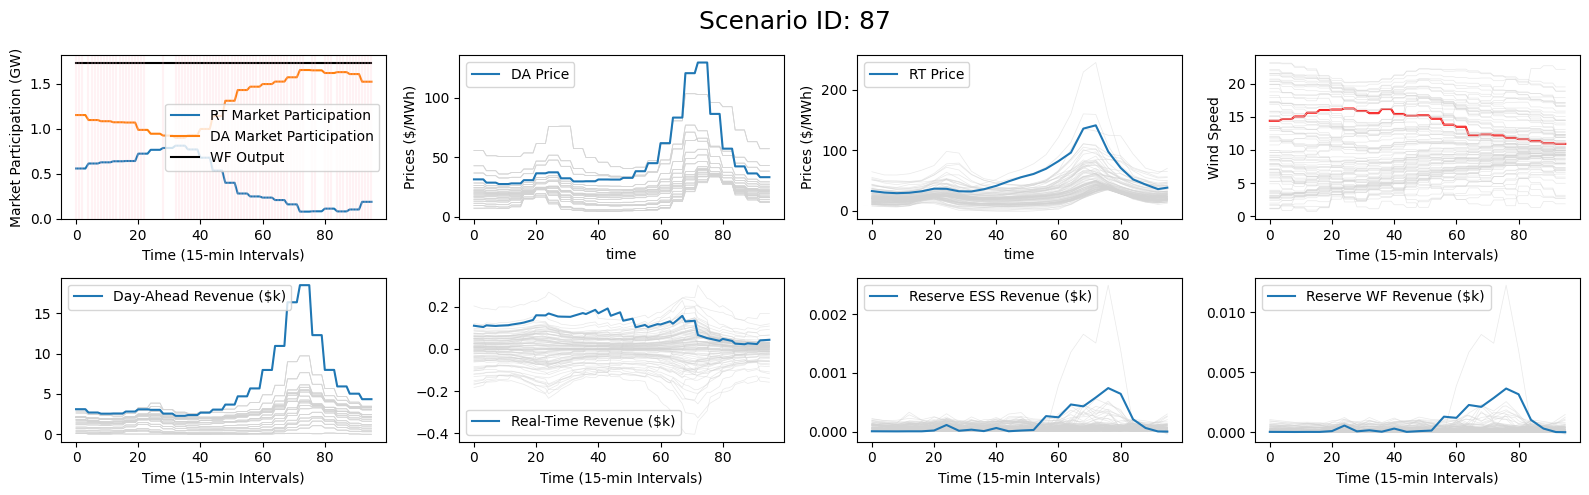

In [13]:
solution_id = df_design_scenario[ovars_scenario].sum(axis=1).sort_values(ascending=False).index.values[0]
plot_scenario(df_scenario.loc[solution_id], rated_power, solution_id)

summary_frame["selected_solution"] = df_design_scenario.loc[solution_id]
summary_frame.iloc[4:]

#### Notes:
- Since day-ahead revenue is the biggest component, the scenario with maximum day-ahead revenue is selected.
- Other revenues are also in the top quartile of the distribution.
- It seems like a windy day with high DA and RT prices.

### Which scenario is the worst - minimal revenue?
In which scenario, do we get minimum total revenue? Total revenue is computed by summing up revenue across all the revenue related objective functions.

,count,mean,std,min,25%,50%,75%,max,selected_solution
Day-Ahead Revenue ($k),100.0,52.037997,32.823280,1.201874,26.837089,52.842652,68.323501,136.196299,1.201874
Real-Time Revenue ($k),100.0,0.290401,6.120973,-17.387559,-3.025179,1.139057,4.716428,17.872314,-0.205468
Reserve WF Revenue ($k),100.0,0.025298,0.026578,0.000046,0.005135,0.018360,0.040850,0.186279,0.000567
Reserve ESS Revenue ($k),100.0,0.007385,0.005302,0.000125,0.003399,0.006763,0.010169,0.038544,0.009071


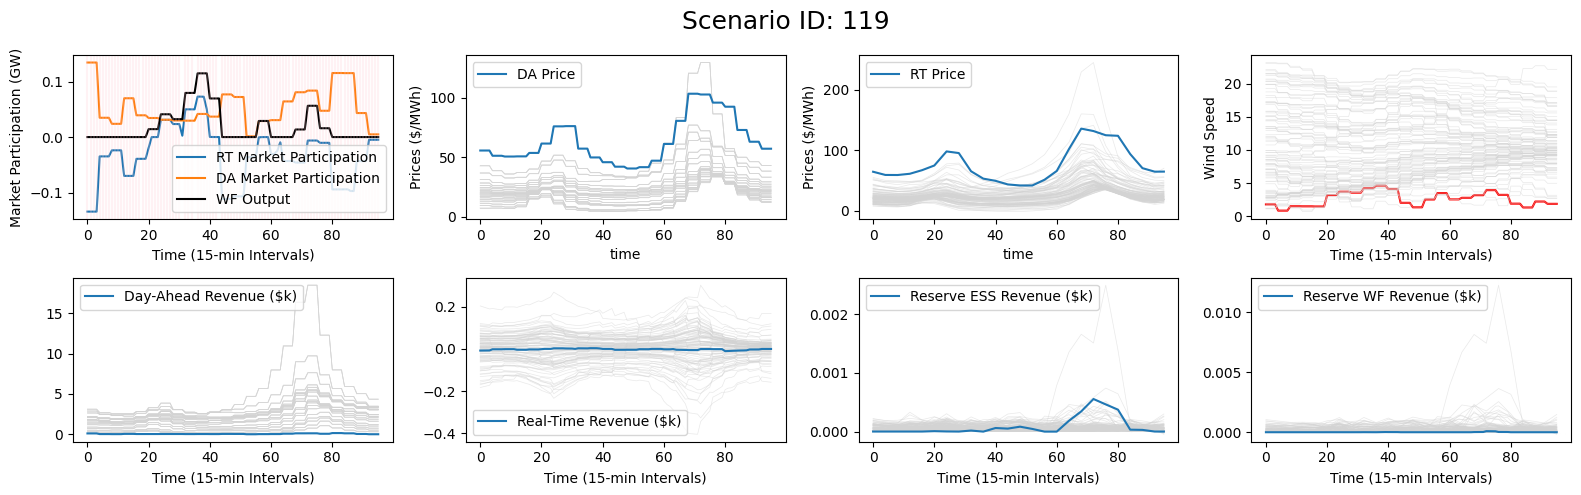

In [14]:
solution_id = df_design_scenario[ovars_scenario].sum(axis=1).sort_values(ascending=True).index.values[0]
plot_scenario(df_scenario.loc[solution_id], rated_power, solution_id)

summary_frame["selected_solution"] = df_design_scenario.loc[solution_id]
summary_frame.iloc[4:]

#### Notes:
- Since day-ahead revenue is the biggest component, the scenario with minimum day-ahead revenue is selected.
- Real-time revenue though is in middle quartile of the distribution.
- The day seems to be least windy even though the DA and RT prices are high.

### In which scenario, the solution is generalizing well across multiple objectives?
To account for uncertainty and variation in conditions, the optimization considers 100 scenarios - a combination of 20 wind conditions and 5 day-ahead market price condition. Can we identify the scenario where the given solution generalize well across multiple objectives

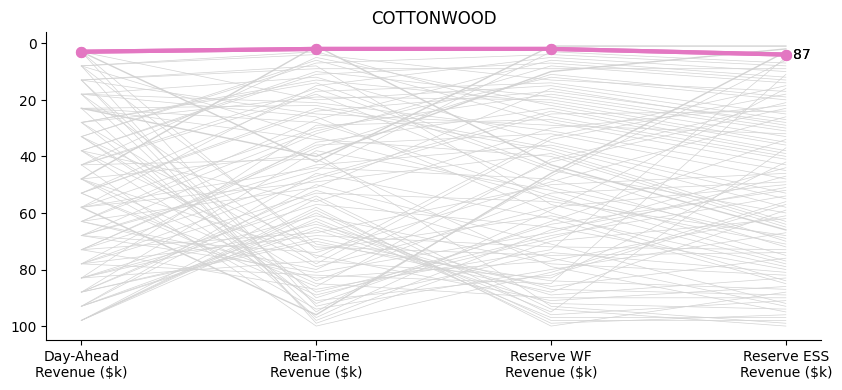

In [15]:
self = tl.DirectTradeoffLattice(
    df_design_scenario, ovars_scenario, dvars,
    ascending=ascending,
    # max_specializers=3,
    # min_specializers=1,
    n_generalizers=1,
)

plt.figure(figsize=(10, 4))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    include_all_generalizers=True,
    reorder=False,
    highlight_generalizers=True,
    # facets = [
    #     i[1]
    #     for i in self.rank.index
    # ]
)
plt.title("COTTONWOOD")

plt.subplots_adjust(hspace=1)

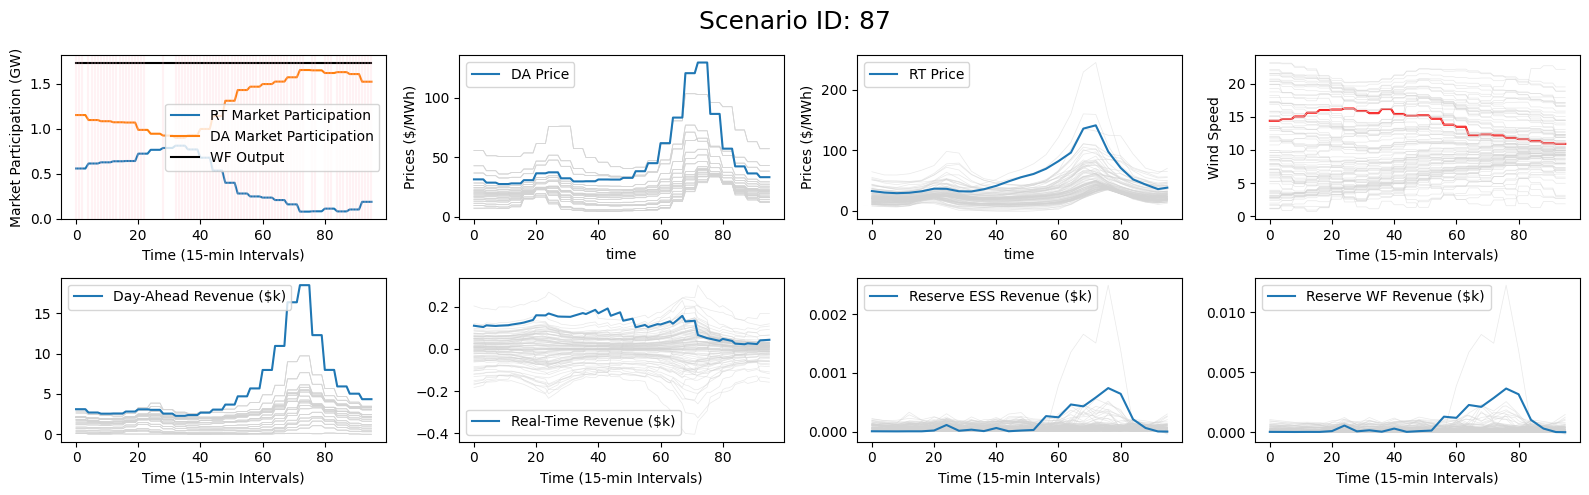

In [16]:
for s in self.generalizers.values:
    plot_scenario(df_scenario.loc[s], rated_power, s)

#### Notes:
- The generalizer is the scenario in which we maximized the total revenue.
- The worst ranking of this scenario is better than any other scenario. 

### In which set of scenarios, the solution is specialising over the generalizer?
To account for uncertainty and variation in conditions, the optimisation considers 100 scenarios - a combination of 20 wind conditions and 5 day-ahead market price conditions. Can we identify scenarios where the given solution is better than the generalizer in at least one objective function?

Text(0.5, 1.0, 'COTTONWOOD')

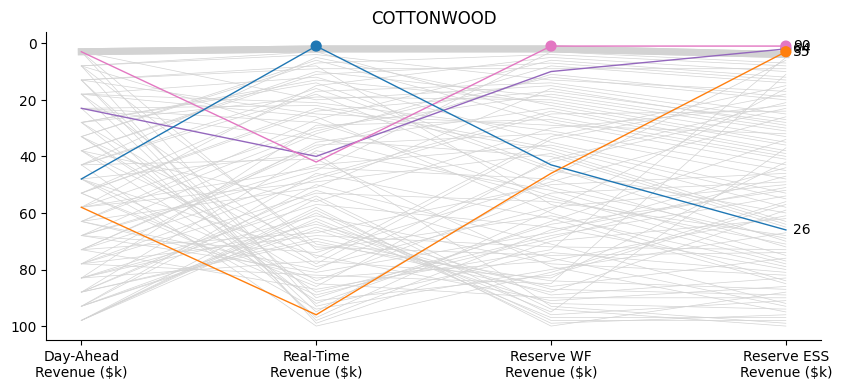

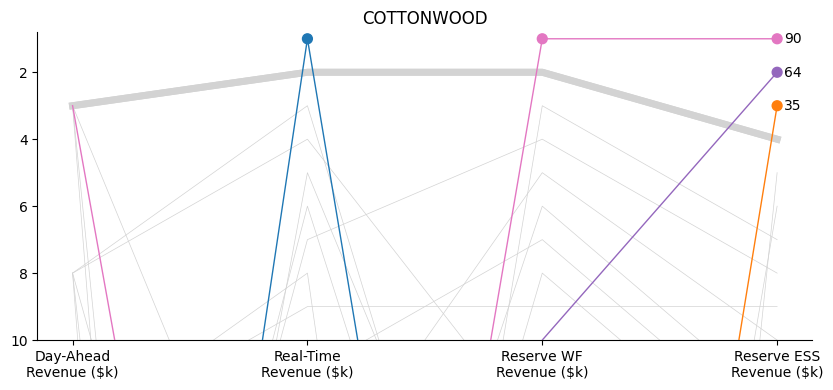

In [17]:
plt.figure(figsize=(10, 4))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    include_all_generalizers=True,
    reorder=False,
    highlight_generalizers=False,
    # facets = [
    #     i[1]
    #     for i in self.rank.index
    # ]
)
# plt.ylim([10, 0.8])
plt.title("COTTONWOOD")

plt.figure(figsize=(10, 4))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    include_all_generalizers=True,
    reorder=False,
    highlight_generalizers=False,
    # facets = [
    #     i[1]
    #     for i in self.rank.index
    # ]
)
plt.ylim([10, 0.8])
plt.title("COTTONWOOD")

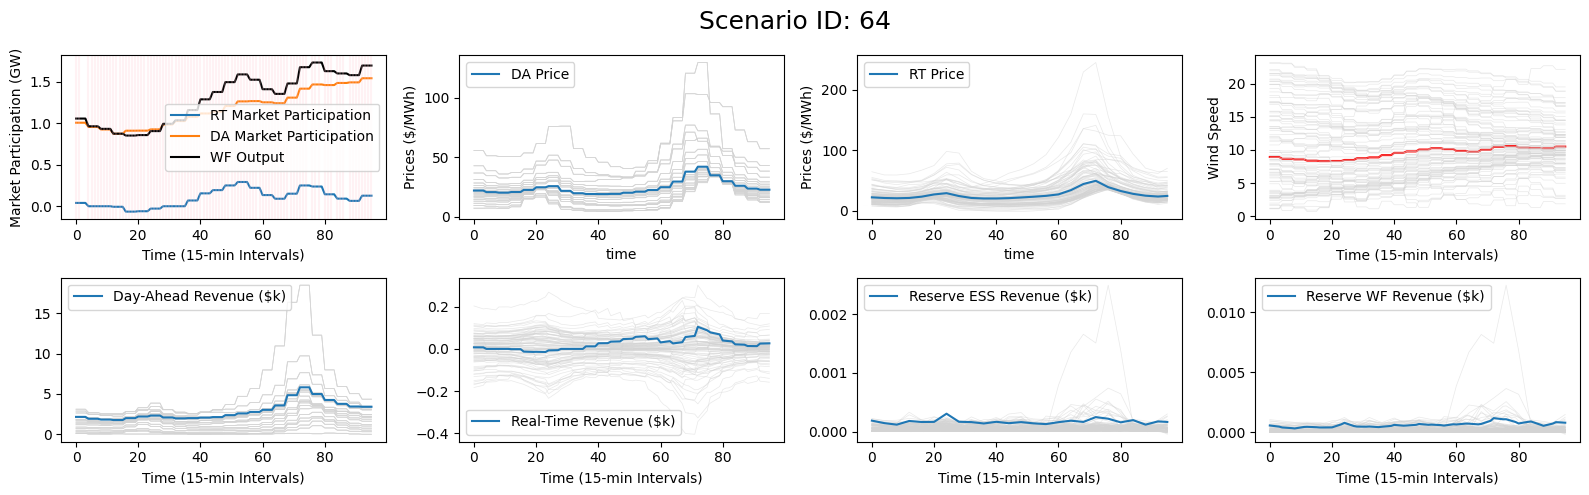

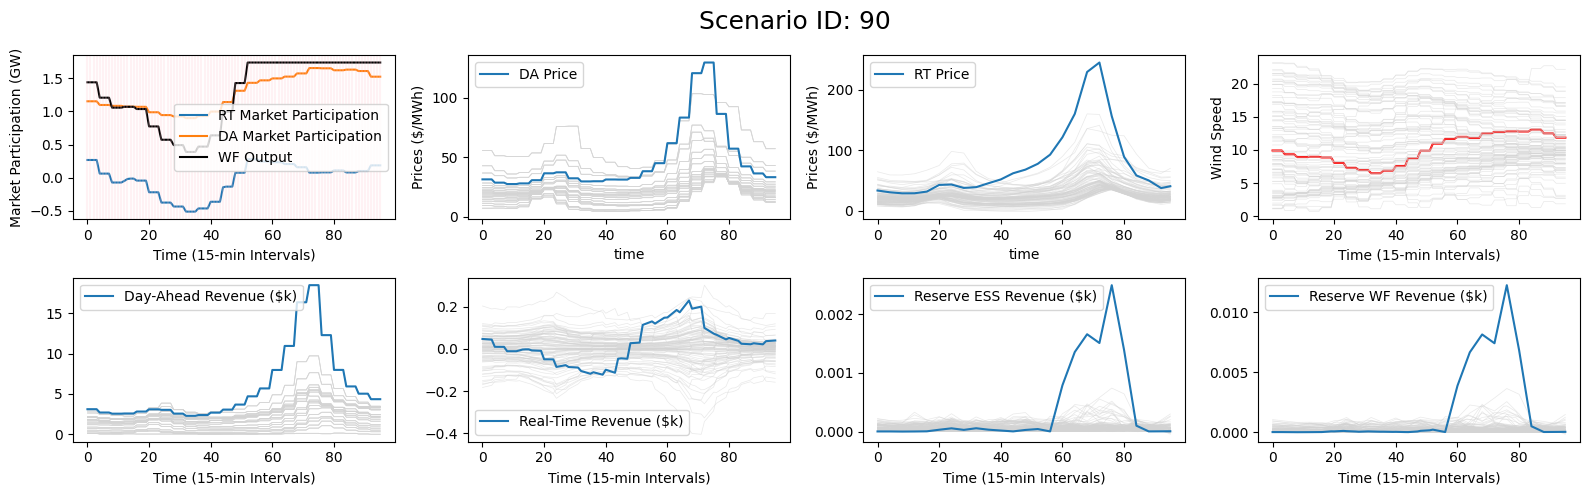

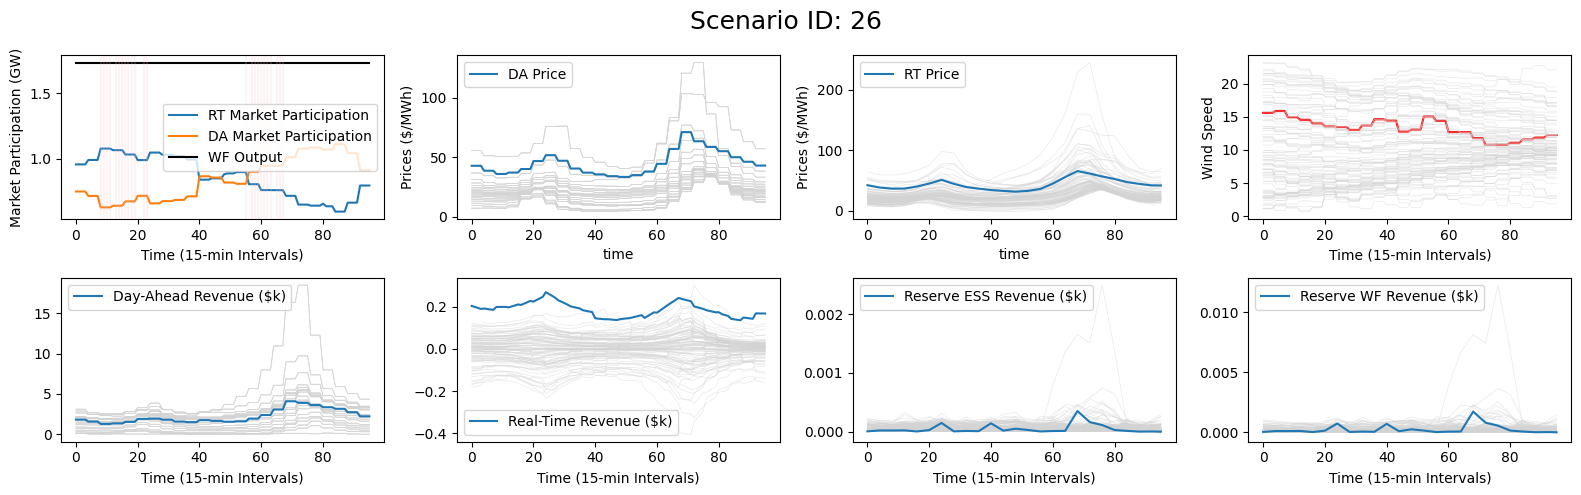

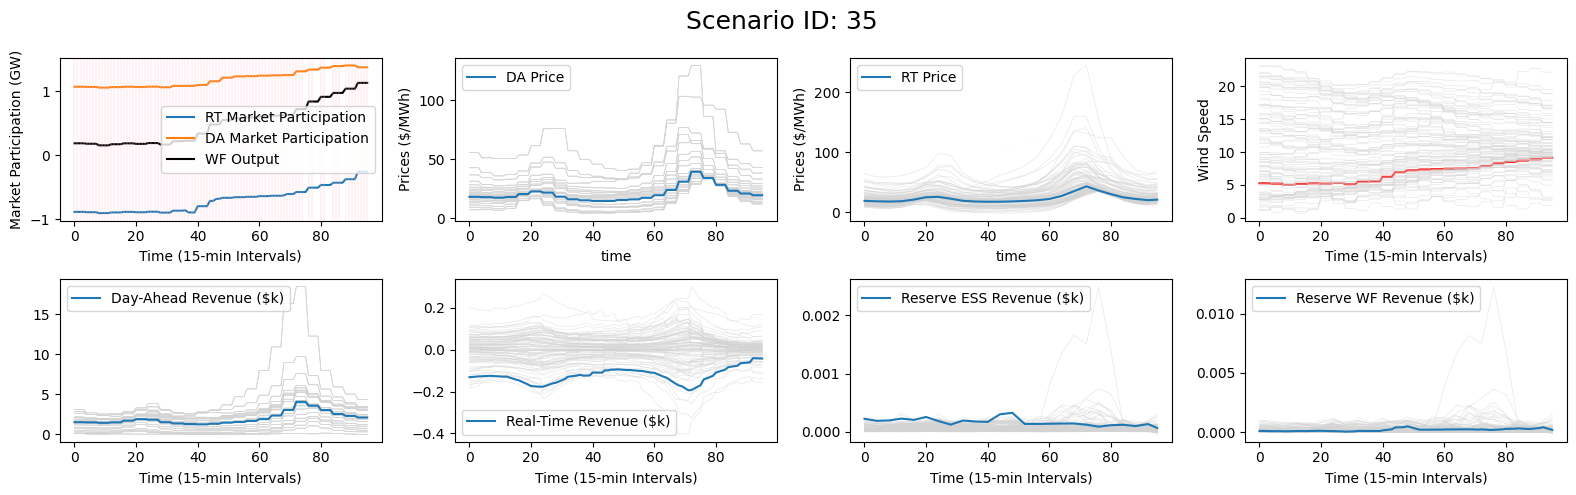

In [18]:
for s in self.specializers.index.values:
    plot_scenario(df_scenario.loc[s], rated_power, s)

### How many more such scenarios exist?

In [19]:
from tslearn.metrics import dtw_path

def closest_series(ts_matrix, reference_col, n=1):
    # Extract reference time series
    reference_ts = ts_matrix[reference_col].values
    
    # Dictionary to store distances
    distances = {}
    
    # Loop through all candidate time series (excluding the reference)
    for col in ts_matrix.columns:
        if col == reference_col:
            continue
        candidate_ts = ts_matrix[col].values.reshape(-1, 1)  # reshape for tslearn compatibility
        _, dist = dtw_path(reference_ts.reshape(-1, 1), candidate_ts)
        distances[col] = dist
    
    # Sort and get top 10 closest
    top_n = sorted(distances.items(), key=lambda x: x[1])[:n]

    return top_n

In [20]:
df_scenario.columns

Index(['ChS', 'DisS', 'SCS', 'WPQ', 'WSQ', 'kBS', 'kWS', 'lam_DAQ', 'lam_RT',
       'pRBDS', 'pRBUS', 'pRWDS', 'pRWUS', 'pWDSQ', 'pWRS', 'pWSQ', 'v1', 'v2',
       'WS', 'pWDS', 'pWS', 'Day-Ahead Revenue ($k)',
       'Reserve ESS Revenue ($k)', 'Reserve WF Revenue ($k)',
       'Real-Time Revenue ($k)'],
      dtype='object')

In [21]:
n = 10
reference_col = 87

# ts_matrix = df_scenario["lam_RT"]-df_scenario["lam_DAQ"]
ts_matrix = df_scenario["WS"]
# ts_matrix = df_scenario["pWRS"] 
top_n = closest_series(ts_matrix.unstack(level=0), reference_col, n)

# Print results
print(f"Top {n} time series closest to '{reference_col}':")
for i, (col, dist) in enumerate(top_n, 1):
    print(f"{i}. {col} — DTW distance: {dist:.4f}")

Top 10 time series closest to '87':
1. 52 — DTW distance: 7.0018
2. 26 — DTW distance: 7.2071
3. 45 — DTW distance: 7.8973
4. 38 — DTW distance: 7.9266
5. 116 — DTW distance: 8.5960
6. 69 — DTW distance: 8.6162
7. 63 — DTW distance: 9.9562
8. 81 — DTW distance: 11.5841
9. 96 — DTW distance: 11.6684
10. 36 — DTW distance: 12.3031


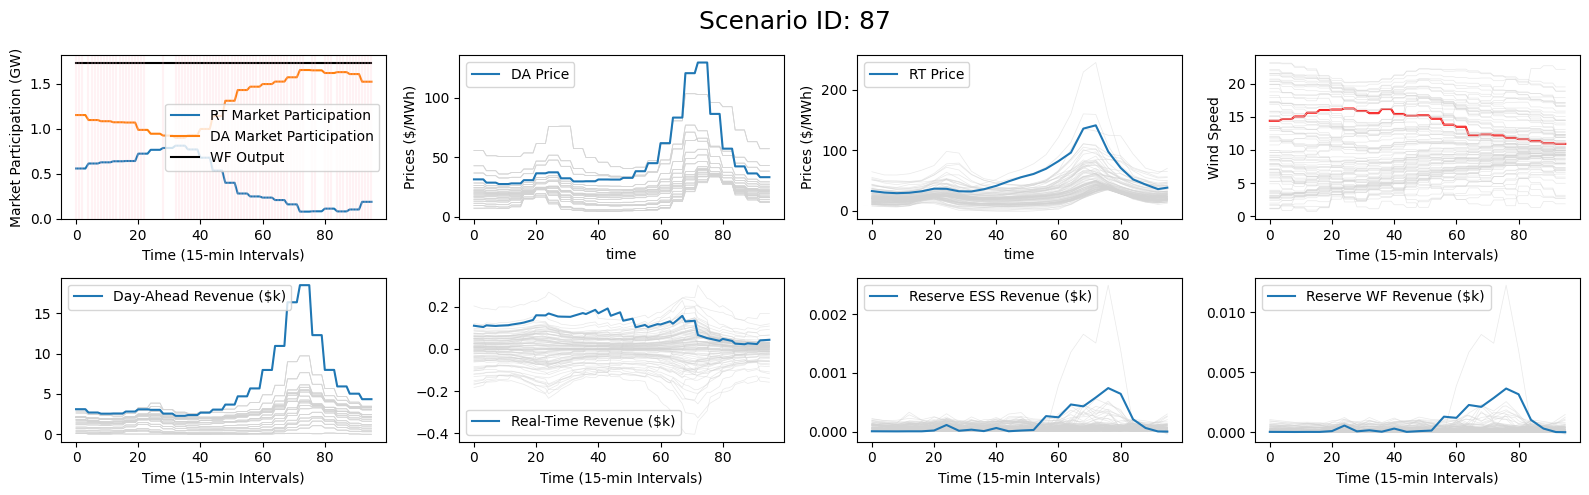

In [22]:
plot_scenario(df_scenario.loc[reference_col], rated_power, reference_col)

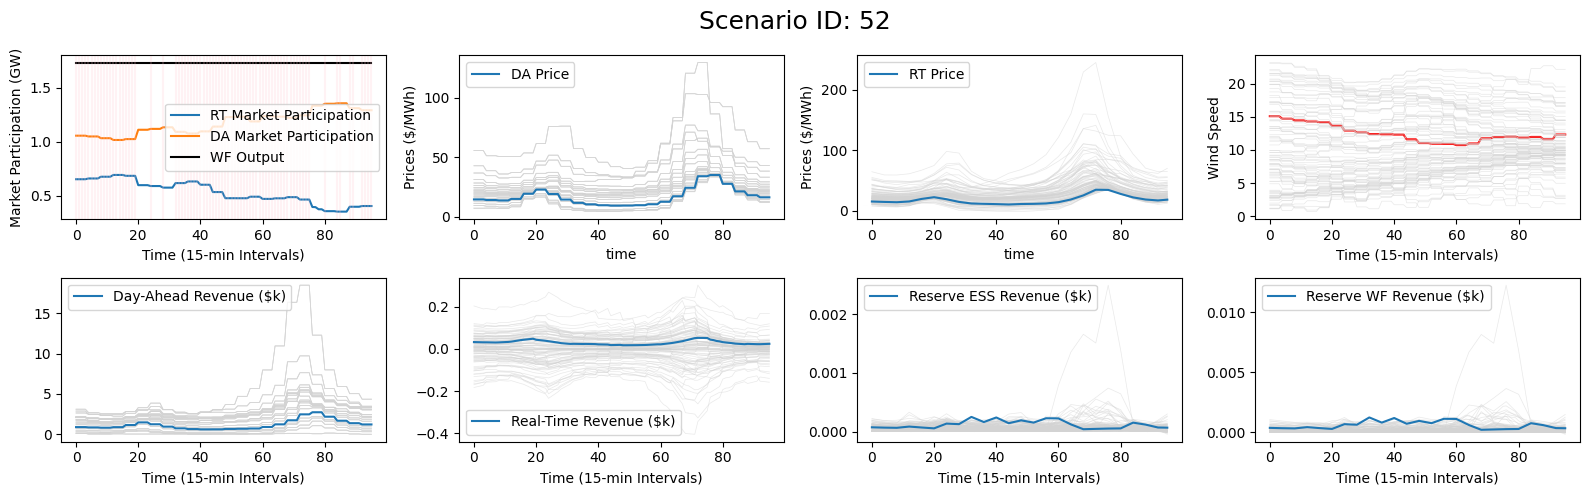

In [23]:
plot_scenario(df_scenario.loc[top_n[0][0]], rated_power, top_n[0][0])

## Univariate Time Series Clustering

In [24]:
df_scenario.columns

Index(['ChS', 'DisS', 'SCS', 'WPQ', 'WSQ', 'kBS', 'kWS', 'lam_DAQ', 'lam_RT',
       'pRBDS', 'pRBUS', 'pRWDS', 'pRWUS', 'pWDSQ', 'pWRS', 'pWSQ', 'v1', 'v2',
       'WS', 'pWDS', 'pWS', 'Day-Ahead Revenue ($k)',
       'Reserve ESS Revenue ($k)', 'Reserve WF Revenue ($k)',
       'Real-Time Revenue ($k)'],
      dtype='object')

In [25]:
seed = 40
n_clusters = 5

### By Wind Speed

/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


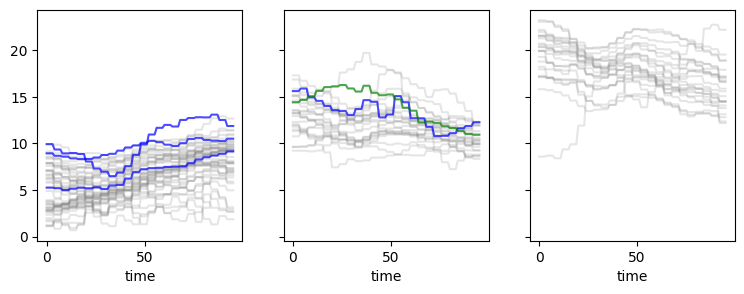

In [26]:
ts_matrix = df_scenario["WS"]
X_train = ts_matrix.unstack(level=1)

n_clusters = 3
model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw",
                         max_iter=10, random_state=seed)
y = model.fit_predict(X_train)

fig, ax = plt.subplots(1, n_clusters, figsize=(3*n_clusters, 3), sharex=True, sharey=True)
for i in range(n_clusters):
    cluster_generalizers = X_train[y==i].index.intersection(self.generalizers)
    cluster_specializers = X_train[y==i].index.intersection(self.specializers.index)
    cluster_else = X_train[y==i].index.difference(self.generalizers.union(self.specializers.index))
    
    if not cluster_else.empty: X_train.loc[cluster_else].T.plot(legend=False, color='grey', ax=ax[i], alpha=0.2)
    if not cluster_specializers.empty: X_train.loc[cluster_specializers].T.plot(legend=False, color='blue', ax=ax[i], alpha=0.7)
    if not cluster_generalizers.empty: X_train.loc[cluster_generalizers].T.plot(legend=False, color='green', ax=ax[i], alpha=0.7)

#### Notes:
- Clustering identifying different types of wind conditions - some clusters can be merged together. 

### By Day Ahead Revenue

/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


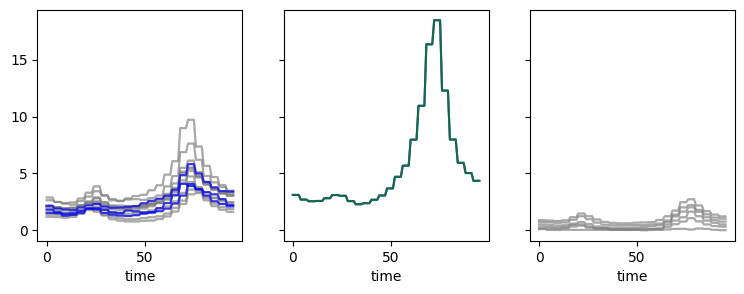

In [27]:
ts_matrix = df_scenario["Day-Ahead Revenue ($k)"]
X_train = ts_matrix.unstack(level=1).T.ffill().T

n_clusters = 3
model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw",
                         max_iter=10, random_state=seed)
y = model.fit_predict(X_train)

fig, ax = plt.subplots(1, n_clusters, figsize=(3*n_clusters, 3), sharex=True, sharey=True)
for i in range(n_clusters):
    cluster_generalizers = X_train[y==i].index.intersection(self.generalizers)
    cluster_specializers = X_train[y==i].index.intersection(self.specializers.index)
    cluster_else = X_train[y==i].index.difference(self.generalizers.union(self.specializers.index))
    
    if not cluster_else.empty: X_train.loc[cluster_else].T.plot(legend=False, color='grey', ax=ax[i], alpha=0.2)
    if not cluster_specializers.empty: X_train.loc[cluster_specializers].T.plot(legend=False, color='blue', ax=ax[i], alpha=0.7)
    if not cluster_generalizers.empty: X_train.loc[cluster_generalizers].T.plot(legend=False, color='green', ax=ax[i], alpha=0.7)

## Multivariate Timeseries Clustering

/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


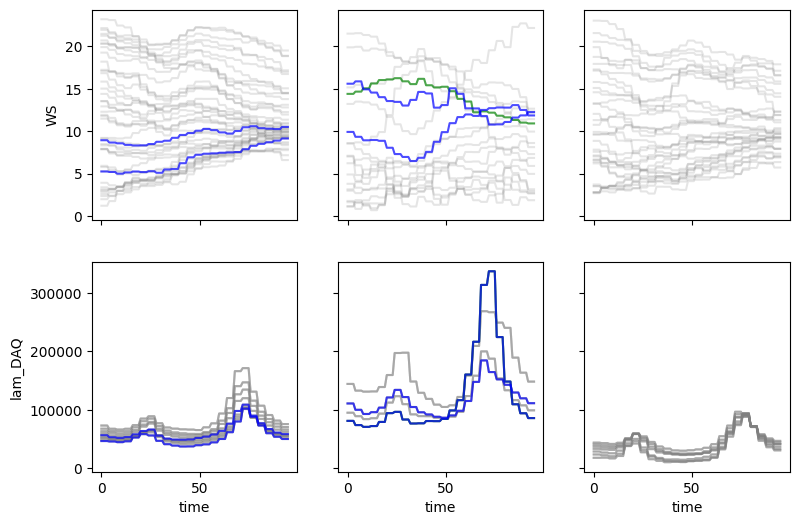

In [28]:
import matplotlib.gridspec as gridspec

cluster_cols = ["WS", "lam_DAQ"]
ts_matrix = df_scenario[cluster_cols].unstack(level='time')
# xr_data = ts_matrix.to_xarray()
# data_3d = xr_data.to_array().values.transpose(1, 2, 0)

model = TimeSeriesKMeans(n_clusters=n_clusters, metric="euclidean",
                         max_iter=10, random_state=seed)
y = model.fit_predict(ts_matrix)

rows = len(cluster_cols)
cols = n_clusters
# fig, ax = plt.subplots(len(cluster_cols), n_clusters, figsize=(3*n_clusters, 3), sharex=True)
fig = plt.figure(figsize=(3 * cols, 3 * rows))
gs = gridspec.GridSpec(rows, cols, figure=fig)

# Create axes with row-wise sharey
axes = []
for row in range(rows):
    row_axes = []
    ax0 = fig.add_subplot(gs[row, 0])
    row_axes.append(ax0)
    for col in range(1, cols):
        ax = fig.add_subplot(gs[row, col], sharey=ax0, sharex=ax0)
        row_axes.append(ax)
    axes.append(row_axes)
    
for row_idx, col_name in enumerate(cluster_cols):
    axes[row_idx][0].set_ylabel(col_name)
    for cluster_idx in range(n_clusters):
        ax = axes[row_idx][cluster_idx]

        cluster_generalizers = ts_matrix[y == cluster_idx].index.intersection(self.generalizers)
        cluster_specializers = ts_matrix[y == cluster_idx].index.intersection(self.specializers.index)
        cluster_else = ts_matrix[y == cluster_idx].index.difference(
            self.generalizers.union(self.specializers.index)
        )

        if not cluster_else.empty:
            ts_matrix.loc[cluster_else, col_name].T.plot(
                legend=False, color='grey', ax=ax, alpha=0.2
            )
        if not cluster_generalizers.empty:
            ts_matrix.loc[cluster_generalizers, col_name].T.plot(
                legend=False, color='green', ax=ax, alpha=0.7
            )
        if not cluster_specializers.empty:
            ts_matrix.loc[cluster_specializers, col_name].T.plot(
                legend=False, color='blue', ax=ax, alpha=0.7
            )

#### Notes:
- lam_DAQ - because of the scale - is driving the clustering

In [29]:
# X_train[y==1]

In [30]:
# from tslearn.clustering import KernelKMeans
# model = KernelKMeans(n_clusters=n_clusters,
#                       kernel="gak",
#                       kernel_params={"sigma": "auto"},
#                       n_init=20,
#                       verbose=True,
#                       random_state=seed)
# y = model.fit_predict(X_train)

# fig, ax = plt.subplots(1, n_clusters, figsize=(3*n_clusters, 4), sharex=True, sharey=True)
# for i in range(n_clusters):
#     cluster_generalizers = X_train[y==i].index.intersection(self.generalizers)
#     cluster_specializers = X_train[y==i].index.intersection(self.specializers.index)
#     cluster_else = X_train[y==i].index.difference(self.generalizers.union(self.specializers.index))
    
#     if not cluster_else.empty: X_train.loc[cluster_else].T.plot(legend=False, color='grey', ax=ax[i], alpha=0.2)
#     if not cluster_generalizers.empty: X_train.loc[cluster_generalizers].T.plot(legend=False, color='green', ax=ax[i], alpha=0.7)
#     if not cluster_specializers.empty: X_train.loc[cluster_specializers].T.plot(legend=False, color='blue', ax=ax[i], alpha=0.7)

In [31]:
### In which cluster does specializer and generalizers lie?

In [32]:
### Can we explain these clusters?